<a href="https://colab.research.google.com/github/Abdi-dotcom/Construction--equipment-Tracking/blob/main/pods_2526_w1_data_inspection_gapminder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Inspection and Subsetting with GapMinder

* 2025/26, Semester 1, Week 1
* PoDS 6G7V0026
* Rochelle Taylor, Luciano Gerber

When we write a notebook, we want to always have some kind of pipeline or workflow that involves the minimum processes that we have to go through to write our notebook.

For any data exploration notebook you will want to do following these steps:

1. Import Libraries and Packages

2. Load Data

3. Inspect the Data

4. First Exploration of the Data

5. Clean the Data

6. Feature Engineering

7. Data Visualisation - second exploration of the data

8. Do we have any more questions...? <font color='blue'>Usually, one would loop back through steps 4-7 as new questions and information arise.</font>

# Reading the Data

## **Importing modules and libraries**
The python programming language comes with a number of built-in functions that can only be called if libraries have first been imported using the import statement.

Note that libraries can be imported at any time **BEFORE** they are required - they do not have to be imported at the start unless the first few cells will utilise them.

*   *Do this at the beginning of every project*

* the essential modules for data visualisation: `matplotlib`, `seaborn`
* ...and for data manipulation: `pandas`, `numpy`

In [ ]:
%matplotlib inline

# Import Python Libraries
import pandas as pd               # pandas mainly works with tabular data, utilises DataFrames and Series
import numpy as np                # NumPy works with numerical data, utilises Arrays
import matplotlib.pyplot as plt   # a plotting library extension of NumPy
import seaborn as sns             # data visualization library based on matplotlib

# Set up the visualisation engine (e.g., default size of figures)
sns.set(
    { "figure.figsize": (8, 6) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_formats = set(('retina', 'svg'))

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

Coding *as plt*, for example, allows a shorter extension to be used so that when the module is called one doesn't have to rewrite the longer name, *matplotlib.pyplot*, but can use the abbreviated *plt*

### The (Simplified) GapMinder Dataset

* We will make use of the simplified `gapminder` dataset, which concerns records of population, life expectancy, and GDP of countries spanning some 50 years. The dataset can be downloaded from [here](https://github.com/Rochelle784/6G7V0026-2526/tree/main/datasets/gapminder.tsv).
    - Have a look at the dataset rendered at the GitHub link and browse its structure and content for a quick understanding of the data.

* It is a tab-separated value (`.tsv`) text file. One is able to see it raw [here](https://raw.githubusercontent.com/Rochelle784/6G7V0026-2526/main/datasets/gapminder.tsv).

* For more on `gapminder`, you might want to check some of [Hans Rosling's TED talks](https://www.ted.com/playlists/474/the_best_hans_rosling_talks_yo) or the book [Factfulness: Ten Reasons We're Wrong About the World--and Why Things Are Better Than You Think](https://g.co/kgs/bEBSWN).

* I have added the dataset to my GitHub for convenience.

## **Uploading datafiles from a local file repository or web address**

There are multiple ways to do this and they depend on whether data is stored locally or scrapped from the web but we will start off simple.

Also remember to specify how the file will be read, i.e. comma-separated, tab-separated, semi-colon-separated, etc. Here we will use tab-separation.

In [ ]:
gm = pd.read_csv(
    'https://raw.githubusercontent.com/Rochelle784/6G7V0026-2526/main/datasets/gapminder.tsv',
    sep='\t'
)

The Pandas library allows data to be loaded in lots of formats JSON, .sql, <font color='red'>.csv, .xlsx</font>, .html, .text, images, etc.

# Analysing the Data

#### Inspect data

* **df.head()**         &emsp;<font color='green'># returns top n (5 by default, up to 60) rows of a data frame or series</font>
* **df.tail()**         &emsp;<font color='green'># returns bottom n (5 by default, up to 60) rows of a data frame or series</font>
* **df.sample()**       &emsp;<font color='green'># returns a random sample (default is 1) of the list without repeats</font>

#### Summarise data

* **df.info()**        &emsp;<font color='green'># returns a concise summary of the DataFrame</font>
* **df.describe()**    &emsp;<font color='green'># computes a summary of statistics relating to the DataFrame columns</font>
* **df.shape**       &emsp;<font color='green'># returns the number of rows and the number of columns</font>
* **len(df)**       &emsp;<font color='green'># returns the number of rows</font>
* **df.size**       &emsp;<font color='green'># returns the number of rows * the number of columns</font>
* **df['ColumnName'].size**       &emsp;<font color='green'># returns the number of rows in a specific column</font>
* **df.describe()**    &emsp;<font color='green'># computes a summary of statistics relating to the DataFrame columns</font>

#### Descriptive statistics

* **df.count()**          &emsp;<font color='green'># returns number of non-null observations</font>
* **df.sum()**            &emsp;<font color='green'># returns sum of values</font>
* **df.mean()**           &emsp;<font color='green'># returns mean of values</font>
* **df.median()**         &emsp;<font color='green'># returns median of values</font>
* **df.mode()**           &emsp;<font color='green'># returns mode of values</font>
* **df.std()**            &emsp;<font color='green'># returns standard deviation of the values</font>
* **df.min()**            &emsp;<font color='green'># returns minimum value</font>
* **df.max()**            &emsp;<font color='green'># returns maximum value</font>
<p>
* **df['ColumnName'].value_counts()**  &emsp;<font color='green'># computes a Series containing counts of non-null values only on specified column</font></p>

## Inspect the Data

We will start by inspecting the data. There are multiple ways to do this but it's important to get a sense of what the data is (shape, types, etc.) so that one can clean the data and frame research and data science questions for data exploration.

The default for `.head()` and `.tail()` are 5 rows and for `.sample()` it's 1 row

In [ ]:
# Let us inspect the data by taking the top 5 rows (5 is by default for this method)
gm.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [ ]:
# We can specify how many of the top rows we want to view (up to 60)
gm.head(3)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710


In [ ]:
gm.sample() # Default is 1 row for this method

,country,continent,year,lifeExp,pop,gdpPercap
1290,Rwanda,Africa,1982,46.218,5507565,881.570647


In [ ]:
gm.sample(5) # We can ask to view more rows by inserting a number in the brackets

,country,continent,year,lifeExp,pop,gdpPercap
48,Argentina,Americas,1952,62.485,17876956,5911.315053
1441,Sudan,Africa,1957,39.624,9753392,1770.337074
445,Ecuador,Americas,1957,51.356,4058385,3780.546651
1241,Portugal,Europe,1977,70.410,9662600,10172.485720
892,Liberia,Africa,1972,42.614,1482628,803.005454


Notice that each time we run the cell above that the displayed rows change. These are displayed randomly.

In [ ]:
# View the bottom few rows
gm.tail(12)

,country,continent,year,lifeExp,pop,gdpPercap
1692,Zimbabwe,Africa,1952,48.451,3080907,406.884115
1693,Zimbabwe,Africa,1957,50.469,3646340,518.764268
1694,Zimbabwe,Africa,1962,52.358,4277736,527.272182
1695,Zimbabwe,Africa,1967,53.995,4995432,569.795071
1696,Zimbabwe,Africa,1972,55.635,5861135,799.362176
1697,Zimbabwe,Africa,1977,57.674,6642107,685.587682
1698,Zimbabwe,Africa,1982,60.363,7636524,788.855041
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960


<span style="color: #3CB371"><b>CHECKPOINT</b>: Please write the corresponding code to (i) inspect the first 20 rows of the dataset, and (ii) sample at least 10 observations from the dataset.</span>

## Summarise the Data

`.shape` helps us keep track of the volume of data dropped during cleaning

In [ ]:
gm.shape # returns number of rows and number of columns

(1704, 6)

Provides the number of rows, number of columns, names of each column alongside their data type,
how many of each dtype we have, gives us info about any null values (important for data cleaning)

In [ ]:
# .info() method
gm.info() # returns a concise summary of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [ ]:
len(gm)

1704

## Descriptive Statistics

Breaks down info into columns where dtype = integer or float, NOT object,
gives number of rows, mean, std deviation, min, max, IQR

In [ ]:
gm.describe().round(2) # computes a summary of statistics relating to the DataFrame columns, rounded to 2 d.p

,year,lifeExp,pop,gdpPercap
count,1704.00,1704.00,1.704000e+03,1704.00
mean,1979.50,59.47,2.960121e+07,7215.33
std,17.27,12.92,1.061579e+08,9857.45
min,1952.00,23.60,6.001100e+04,241.17
25%,1965.75,48.20,2.793664e+06,1202.06
50%,1979.50,60.71,7.023596e+06,3531.85
75%,1993.25,70.85,1.958522e+07,9325.46
max,2007.00,82.60,1.318683e+09,113523.13


### A Data Science Question

* How does the data distribution of life expectancy vary over the 55 years of observations? Are there any clear trends or patterns?

To answer we could try to visualise the data, uniaxially.

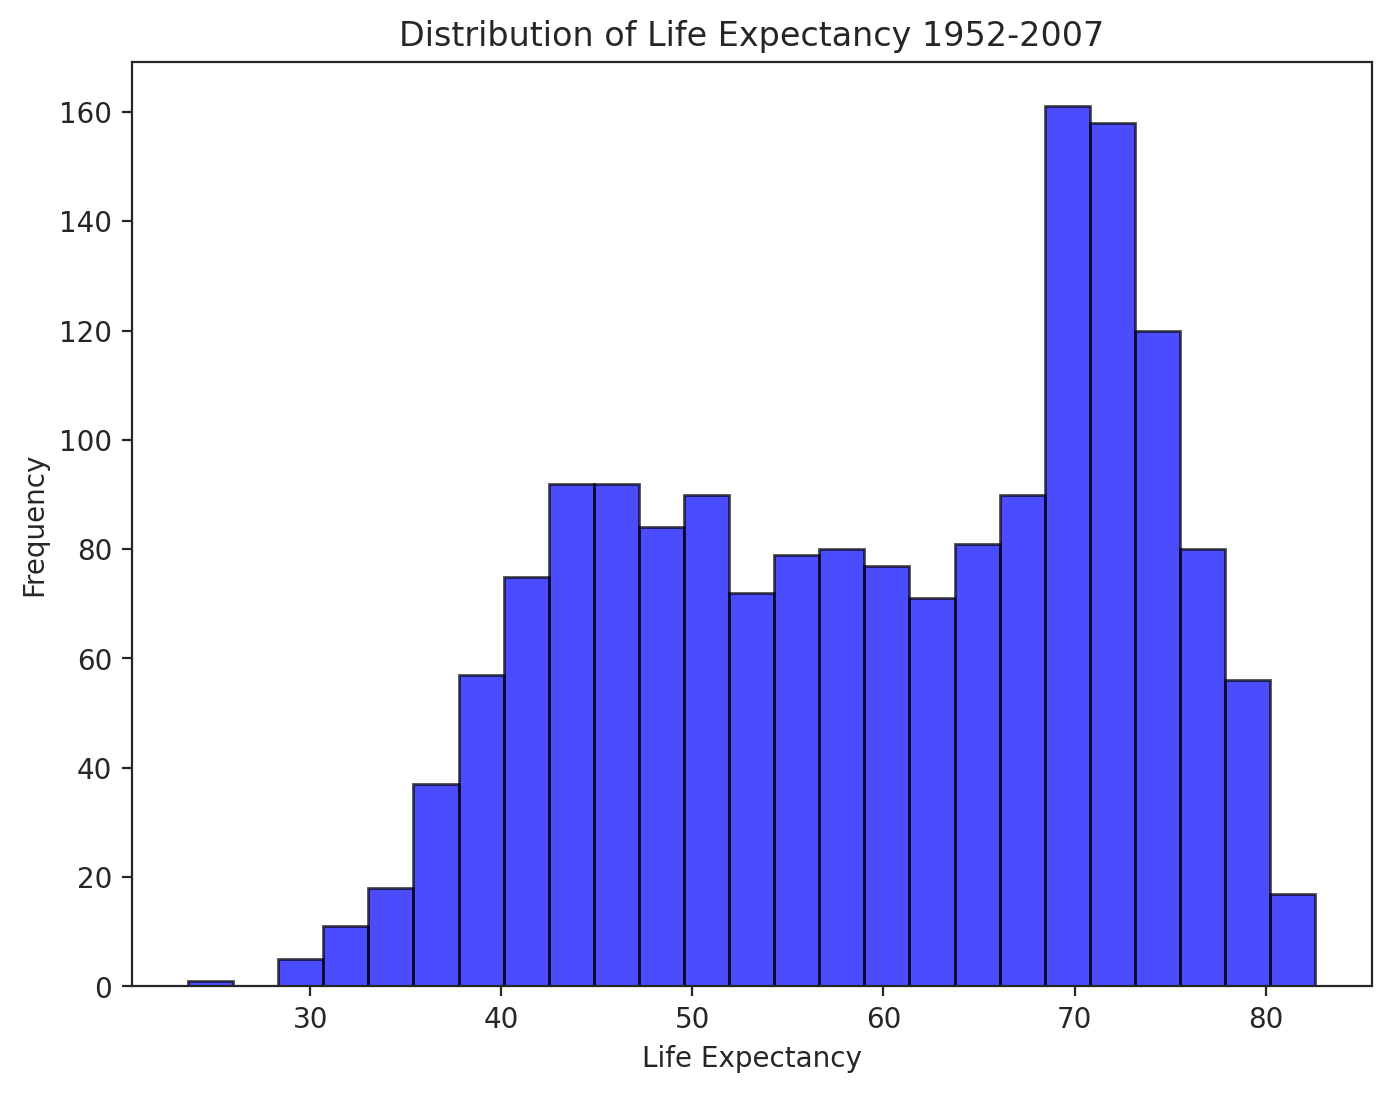

In [ ]:
# Plotting the histogram
plt.hist(gm['lifeExp'], bins=25, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.title('Distribution of Life Expectancy 1952-2007')
plt.show()

<span style="color: #3CB371"><b>CHECKPOINT</b>: Try adjusting the bin size. Does it affect your interpretation of the data?</span>

Remember the boxplot that was plotted in Machine Learning Concepts...this is a biaxial plot because it plots **two** features.

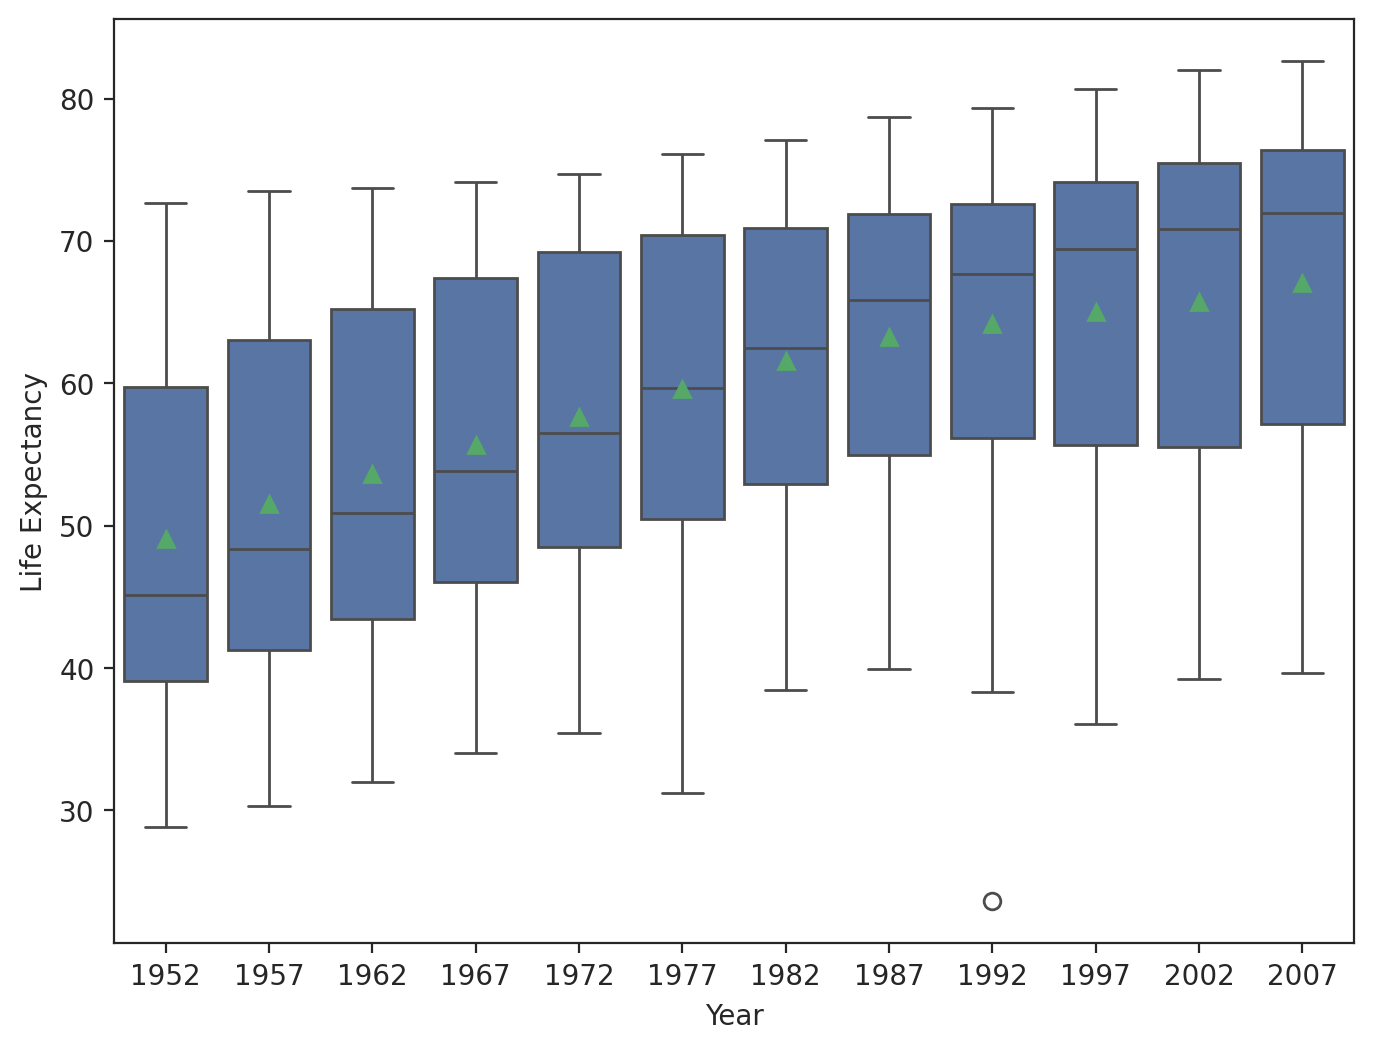

In [ ]:
ax = sns.boxplot(x='year', y='lifeExp', showmeans=True, data=gm)
ax.set_ylabel('Life Expectancy')
ax.set_xlabel('Year');

Can we say anything more about our original question?

### Subsetting DataFrames by Specifying Row and Column Labels

Remember that **Dataframes** are **objects** that can be seen as tabular structures with **rows** and **columns**. Rows and columns are associated with **indices**, and indices contain **labels**. One can think of each label being a name of a column (i.e., a header) or of a row (i.e., a row number).

Accessing individual rows and columns is achieved via the operator `[]` or the property `.loc[]`.

In many scenarios, the application of a method such as `.head()` or `.loc[]` on a DataFrame returns a new DataFrame object (or view of an object, but let us not worry about this right now).

In [ ]:
gm['year'].head()

,year
0,1952
1,1957
2,1962
3,1967
4,1972


We can view the same information by using the following code - there's often **many different ways** to code the same output!

In [ ]:
gm.head()['year']

,year
0,1952
1,1957
2,1962
3,1967
4,1972


If we want to access a particular row, we can use the `.loc[]` property and specify the row number (first row = 0)

In [ ]:
gm.loc[0]

,0
country,Afghanistan
continent,Asia
year,1952
lifeExp,28.801
pop,8425333
gdpPercap,779.445314


If we only want one feature in that row, we can build on the code line. In this case, adding the feature name within the square [ ] brackets

In [ ]:
gm.loc[0, 'lifeExp']

28.801

In [ ]:
gm.loc[0]['lifeExp']

28.801

Instead of using a single row or column label, one can provide **a list** of labels.

In [ ]:
gm.loc[ [0,12,24] ]

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
12,Albania,Europe,1952,55.230,1282697,1601.056136
24,Algeria,Africa,1952,43.077,9279525,2449.008185


In [ ]:
gm[ ['country', 'year', 'lifeExp'] ]

,country,year,lifeExp
0,Afghanistan,1952,28.801
1,Afghanistan,1957,30.332
2,Afghanistan,1962,31.997
3,Afghanistan,1967,34.020
4,Afghanistan,1972,36.088
...,...,...,...
1699,Zimbabwe,1987,62.351
1700,Zimbabwe,1992,60.377
1701,Zimbabwe,1997,46.809
1702,Zimbabwe,2002,39.989


And we can subset specific rows and columns.

In [ ]:
gm.loc[ [0,12,24], ['country', 'year', 'lifeExp'] ]

,country,year,lifeExp
0,Afghanistan,1952,28.801
12,Albania,1952,55.230
24,Algeria,1952,43.077


### Subsetting DataFrames with Logical Conditions

We might only be interested in a certain `year` or `continent` so we can place conditions on our subset.

In [ ]:
gm.loc[ gm['year'] == 1952 ].head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
12,Albania,Europe,1952,55.230,1282697,1601.056136
24,Algeria,Africa,1952,43.077,9279525,2449.008185
36,Angola,Africa,1952,30.015,4232095,3520.610273
48,Argentina,Americas,1952,62.485,17876956,5911.315053


In [ ]:
gm.query("year==1952").head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
12,Albania,Europe,1952,55.230,1282697,1601.056136
24,Algeria,Africa,1952,43.077,9279525,2449.008185
36,Angola,Africa,1952,30.015,4232095,3520.610273
48,Argentina,Americas,1952,62.485,17876956,5911.315053


Both methods produce the same results but `.loc` is used for label-based indexing so it directly accesses the DataFrame's index and columns. The `.query()` method involves parsing the query string and translating the filtering operation so it can often be slower. It really depends on the complexity of the condition used for filtering.

For simpler conditions, both methods perform similarly but `.loc` doesn't have the overhead of parsing so may be slightly quicker. whilst `.query()` may be slower, it can be more readable so may work better for complex conditions or large DataFrames.

We can also subset based on column values.

In [ ]:
gm.loc[gm['country'].isin(['Angola', 'Vietnam'])]

,country,continent,year,lifeExp,pop,gdpPercap
36,Angola,Africa,1952,30.015,4232095,3520.610273
37,Angola,Africa,1957,31.999,4561361,3827.940465
38,Angola,Africa,1962,34.000,4826015,4269.276742
39,Angola,Africa,1967,35.985,5247469,5522.776375
40,Angola,Africa,1972,37.928,5894858,5473.288005
41,Angola,Africa,1977,39.483,6162675,3008.647355
42,Angola,Africa,1982,39.942,7016384,2756.953672
43,Angola,Africa,1987,39.906,7874230,2430.208311
44,Angola,Africa,1992,40.647,8735988,2627.845685
45,Angola,Africa,1997,40.963,9875024,2277.140884


**CHECKPOINT**: It is a good idea to practice some of the above. You could write code cells that do the following:

* Perhaps you would like to play with code on ranges above and try some alternatives?
* Display only columns `continent`, `lifeExp` and `pop`.
* Try to select all rows where the value of `lifeExp` is greater than 58.
* Now produce a DataFrame where the `lifeExp` is greater than 58 and only `continent`, `lifeExp` and `pop` are displayed.

How about any countries that have had a life expectancy equal to or greater than 80 years?

In [ ]:
gm.loc[ gm['lifeExp']>=80  ]

,country,continent,year,lifeExp,pop,gdpPercap
70,Australia,Oceania,2002,80.370,19546792,30687.75473
71,Australia,Oceania,2007,81.235,20434176,34435.36744
251,Canada,Americas,2007,80.653,33390141,36319.23501
539,France,Europe,2007,80.657,61083916,30470.01670
669,"Hong Kong, China",Asia,1997,80.000,6495918,28377.63219
670,"Hong Kong, China",Asia,2002,81.495,6762476,30209.01516
671,"Hong Kong, China",Asia,2007,82.208,6980412,39724.97867
694,Iceland,Europe,2002,80.500,288030,31163.20196
695,Iceland,Europe,2007,81.757,301931,36180.78919
767,Israel,Asia,2007,80.745,6426679,25523.27710


OK, some countries appear more than once. Can I get a quick list of unique country names? Yes, I can. It is worth emphasising that one can **chain** DataFrame-producing statements, creating pipelines. The output of one method becomes the input of another.

In [ ]:
gm.loc[ gm['lifeExp']>=80 ]['country'].drop_duplicates()

,country
70,Australia
251,Canada
539,France
669,"Hong Kong, China"
694,Iceland
767,Israel
778,Italy
801,Japan
1103,New Zealand
1151,Norway


<span style="color: #3CB371">
<strong>CHECKPOINT:</strong> Could you write code cells for retrieving the following subsets of data?

* all the observations in 1952.
* all those that have a GDP-per-capita greater than US$30K.
* are there any instances where life expectancy was lower than 30 years?

In [ ]:
# all the observations in 1952


In [ ]:
# all those that have a GDP-per-capita greater than US$30K


In [ ]:
# are there any instances where life expectancy was lower than 30 years?


### Subsetting DataFrames: Multiple Conditions

What if we want to know something in particular, say, what countries on the Asian continent have a low life expectancy (below 35 years)?

In [ ]:
gm.query("lifeExp<35 and continent=='Asia'")

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
221,Cambodia,Asia,1977,31.220,6978607,524.972183
1668,"Yemen, Rep.",Asia,1952,32.548,4963829,781.717576
1669,"Yemen, Rep.",Asia,1957,33.970,5498090,804.830455


We can also use `.loc` but rememember that you will need the brackets to make sure that the evaluation order is correct. Also notice that the boolean operators change from `and` to `&`, `or` to `|`.

In [ ]:
gm.loc[   (gm['lifeExp']<35) & (gm['continent']=='Asia')    ]

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
221,Cambodia,Asia,1977,31.220,6978607,524.972183
1668,"Yemen, Rep.",Asia,1952,32.548,4963829,781.717576
1669,"Yemen, Rep.",Asia,1957,33.970,5498090,804.830455


The latest year a country had a low life expectancy in Asia was 1977. Perhaps it would be useful to know which countries on the Asian continent had a high life expectancy (above 70 years) in 1977 and earlier?

In [ ]:
gm.query("lifeExp>70 and continent=='Asia' and year<=1977")

,country,continent,year,lifeExp,pop,gdpPercap
664,"Hong Kong, China",Asia,1972,72.000,4115700,8315.928145
665,"Hong Kong, China",Asia,1977,73.600,4583700,11186.141250
759,Israel,Asia,1967,70.750,2693585,8393.741404
760,Israel,Asia,1972,71.630,3095893,12786.932230
761,Israel,Asia,1977,73.060,3495918,13306.619210
795,Japan,Asia,1967,71.430,100825279,9847.788607
796,Japan,Asia,1972,73.420,107188273,14778.786360
797,Japan,Asia,1977,75.380,113872473,16610.377010
1361,Singapore,Asia,1977,70.795,2325300,11210.089480
1505,Taiwan,Asia,1977,70.590,16785196,5596.519826


<span style="color: #3CB371">**CHECKPOINT:** Can you discuss your findings? What data science questions would arise from these queries and can you think about what data visualisations would be suitable to provide more useful information to answer these questions?</span>

We can use `.shape` or `len` to show us how large the subset is.

In [ ]:
subset_df = gm.loc[ (gm['lifeExp']<35) & (gm['continent']=='Asia')  ]
len(subset_df)

7

<h2 style="color: #3CB371">Exercises</h2>

As a reminder, this is the DataFrame we are starting with:

In [ ]:
gm.head(1)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314


1. Select only the observations for the year of 1972.

2. For the resulting DataFrame of query above, how many data instances there are?

3. Obtain the rows for Brazil only.

4. What are the years for which observations have been recorded? (You might want to check what methods such as `.unique()` and `.value_counts()` can do for you here).

5. And how many different years?

6. What are top-10 countries in 2007 with respect to life expectancy?

7. Obtain the subset of observations for Asia in 2007.

8. Produce the observations for South America for the period between 2000 and 2009. What do you notice about the result?

9. Show life expectancy and GDP-per-capita for Brazil.

10. How many observations do we have for each continent?

11. What is the life expectancy for Brazil measured in 2007?

Please feel free to explore the Dataframe yourself to answer any questions you might have about the data, if you have finished.